# Basic Pitch Note-Capture Experiment Notebook

This is a focused version of the latest working audio-to-tab notebook. It isolates the **audio → Basic Pitch → MIDI note event** stage and evaluates note capture directly against GuitarSet JAMS ground truth.

The goal is to test whether preprocessing/postprocessing ideas improve Basic Pitch note capture before the fretboard/tab assignment layer gets involved.

What this notebook compares:

- Baseline Basic Pitch
- Amplitude threshold sweeps
- Guitar MIDI range filtering
- Minimum note duration filtering
- Same-pitch note merging
- Frequency filtering / bandpass preprocessing
- Harmonic-only preprocessing
- Trim + normalize preprocessing
- Combined preprocessing/postprocessing variants

Main metrics:

- `pitch_precision`: of predicted Basic Pitch notes, how many matched a GT note by pitch + onset?
- `pitch_recall`: of GT notes, how many did Basic Pitch capture?
- `pitch_f1`: balance of precision and recall
- `mean_onset_error_sec`: timing error for matched notes
- `n_false_positives`, `n_missed_gt_notes`

Run a small debug subset first, then set `MAX_AUDIO_RECORDINGS = None` for the full held-out test set.


In [1]:
from pathlib import Path
from collections import defaultdict
import hashlib
import json
import math
import os
import random
import re
import shutil
import subprocess
import sys
import warnings

import numpy as np
import pandas as pd

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 200)



In [2]:
# Mount Google Drive when running in Colab.
# This must run before any /content/drive/MyDrive/... paths are used.
try:
    from google.colab import drive
    drive.mount('/content/drive')
    print('Google Drive mounted successfully.')
except ModuleNotFoundError:
    print('Not running in Colab. Skipping Google Drive mount.')



Mounted at /content/drive
Google Drive mounted successfully.


## 1. Configuration

This uses the same path assumptions as the working notebook:

```text
/content/drive/MyDrive/Capstone/FullGuitarSetData
/content/drive/MyDrive/FullGuitarSetData
```

Expected data structure:

```text
FullGuitarSetData/
├── JamsFiles/
└── AudioFiles/
```

Experiment outputs are saved to:

```text
/content/drive/MyDrive/Capstone/outputs/basic_pitch_note_capture_experiments/
```


In [3]:
# -------------------------
# USER CONFIG
# -------------------------

CAPSTONE_ROOT = Path('/content/drive/MyDrive/Capstone')
OUTPUT_DIR = CAPSTONE_ROOT / 'outputs' / 'basic_pitch_note_capture_experiments'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

DATA_ROOT_CANDIDATES = [
    Path('/content/drive/MyDrive/Capstone/FullGuitarSetData'),
    Path('/content/drive/MyDrive/FullGuitarSetData'),
    Path('/content/drive/MyDrive/Capstone/GuitarSet'),
    Path('/content/drive/MyDrive/GuitarSet'),
    Path('/content/drive/MyDrive/Capstone'),
    Path('/content/drive/MyDrive'),
    Path('/mnt/data/fretwork_repo/GuitarSet'),
    Path('/mnt/data/fretwork_repo'),
]

AUDIO_ROOT_CANDIDATES = [
    CAPSTONE_ROOT / 'GuitarSet' / 'Audio',
    CAPSTONE_ROOT / 'GuitarSet' / 'AudioFiles',
    CAPSTONE_ROOT / 'FullGuitarSetData' / 'AudioFiles',
    CAPSTONE_ROOT / 'FullGuitarSetData' / 'Audio',
    CAPSTONE_ROOT / 'Audio',
    CAPSTONE_ROOT / 'GuitarSet',
    CAPSTONE_ROOT,
    Path('/content/drive/MyDrive/GuitarSet/Audio'),
    Path('/content/drive/MyDrive/GuitarSet'),
]

AUDIO_EXTENSIONS = ['.wav', '.mp3', '.m4a', '.flac', '.ogg']

# Guitar standard tuning range. Keep this wide enough for bends/high frets.
DEFAULT_MIN_MIDI = 40   # low E2
DEFAULT_MAX_MIDI = 88   # high guitar-ish range
OPEN_STRING_MIDI = [40, 45, 50, 55, 59, 64]  # E2, A2, D3, G3, B3, E4

# Matching predicted Basic Pitch notes to GuitarSet GT notes.
AUDIO_MATCH_ONSET_TOLERANCE_SECONDS = 0.05

# Use held-out test split like the original notebook.
USE_HELDOUT_SPLIT = True
SPLIT_SEED = 42
TRAIN_FRAC = 0.70
VAL_FRAC = 0.15
TEST_FRAC = 0.15

# Debug small, then set to None for full test set.
MAX_AUDIO_RECORDINGS = None

# Basic Pitch preprocessing cache.
CACHE_DIR = OUTPUT_DIR / 'cache'
PREPROCESSED_AUDIO_DIR = CACHE_DIR / 'preprocessed_audio'
BASIC_PITCH_NOTE_CACHE_DIR = CACHE_DIR / 'basic_pitch_notes'
for d in [CACHE_DIR, PREPROCESSED_AUDIO_DIR, BASIC_PITCH_NOTE_CACHE_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print('OUTPUT_DIR:', OUTPUT_DIR.resolve())
print('\nData root candidates:')
for p in DATA_ROOT_CANDIDATES:
    print(f' - {p} | exists: {p.exists()}')
print('\nAudio root candidates:')
for p in AUDIO_ROOT_CANDIDATES:
    print(f' - {p} | exists: {p.exists()}')




OUTPUT_DIR: /content/drive/.shortcut-targets-by-id/1JNqe8bukG93wCWVxbk7SKlNvVyIZHyTC/Capstone/outputs/basic_pitch_note_capture_experiments

Data root candidates:
 - /content/drive/MyDrive/Capstone/FullGuitarSetData | exists: True
 - /content/drive/MyDrive/FullGuitarSetData | exists: False
 - /content/drive/MyDrive/Capstone/GuitarSet | exists: True
 - /content/drive/MyDrive/GuitarSet | exists: False
 - /content/drive/MyDrive/Capstone | exists: True
 - /content/drive/MyDrive | exists: True
 - /mnt/data/fretwork_repo/GuitarSet | exists: False
 - /mnt/data/fretwork_repo | exists: False

Audio root candidates:
 - /content/drive/MyDrive/Capstone/GuitarSet/Audio | exists: True
 - /content/drive/MyDrive/Capstone/GuitarSet/AudioFiles | exists: False
 - /content/drive/MyDrive/Capstone/FullGuitarSetData/AudioFiles | exists: True
 - /content/drive/MyDrive/Capstone/FullGuitarSetData/Audio | exists: False
 - /content/drive/MyDrive/Capstone/Audio | exists: True
 - /content/drive/MyDrive/Capstone/Guit

## 2. Install / import Basic Pitch environment

This is copied from the working notebook style and includes the Python 3.12 `pkgutil.ImpImporter` patch used for Colab.

Run this once after restarting the runtime.


In [4]:
# ============================================================
# FIX-ALL Basic Pitch install/import cell for Colab Python 3.12
# Run this ONCE after Runtime -> Restart runtime
# ============================================================

import importlib
import pkgutil
import zipimport

print('Python:', sys.version)

def run(cmd):
    print('\n$', ' '.join(cmd))
    subprocess.check_call(cmd)

# Some Colab/system pkg_resources versions expect pkgutil.ImpImporter,
# which was removed in Python 3.12.
if not hasattr(pkgutil, 'ImpImporter'):
    pkgutil.ImpImporter = zipimport.zipimporter

run([sys.executable, '-m', 'pip', 'install', '-q', '--upgrade', 'pip', 'wheel', 'setuptools==80.9.0'])

run([sys.executable, '-m', 'pip', 'install', '-q',
     'librosa>=0.10',
     'soundfile',
     'mir-eval',
     'pretty_midi',
     'resampy==0.4.2',
     'onnxruntime',
     'scipy'])

run([sys.executable, '-m', 'pip', 'install', '-q', '--no-deps', 'basic-pitch==0.4.0'])

if not hasattr(pkgutil, 'ImpImporter'):
    pkgutil.ImpImporter = zipimport.zipimporter

import librosa
import soundfile as sf
from scipy import signal
from basic_pitch.inference import predict as basic_pitch_predict

print('\n✅ Basic Pitch import successful.')
print('✅ librosa:', librosa.__version__)
print('✅ soundfile import successful.')
print('✅ scipy signal import successful.')
print('✅ onnxruntime installed.')



Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]

$ /usr/bin/python3 -m pip install -q --upgrade pip wheel setuptools==80.9.0

$ /usr/bin/python3 -m pip install -q librosa>=0.10 soundfile mir-eval pretty_midi resampy==0.4.2 onnxruntime scipy

$ /usr/bin/python3 -m pip install -q --no-deps basic-pitch==0.4.0



✅ Basic Pitch import successful.
✅ librosa: 0.11.0
✅ soundfile import successful.
✅ scipy signal import successful.
✅ onnxruntime installed.


## 3. GuitarSet JAMS parsing

This section reads GuitarSet `.jams` files directly without requiring the external `jams` package. Ground truth is used only for scoring Basic Pitch note capture.


In [5]:
def find_jams_dir(data_root):
    """Return a directory containing .jams files under data_root, or None if not found."""
    candidates = [
        data_root / 'JamsFiles',
        data_root / 'Annotations',
        data_root / 'GuitarSet' / 'Annotations',
        data_root / 'FullGuitarSetData' / 'JamsFiles',
        data_root / 'FullGuitarSetData' / 'Annotations',
        data_root,
    ]
    for c in candidates:
        if c.exists() and list(c.glob('*.jams')):
            return c

    if data_root.exists():
        try:
            for match in data_root.rglob('*.jams'):
                return match.parent
        except Exception as e:
            print(f'Could not recursively search {data_root}: {e}')
    return None


def choose_data_root_and_jams_dir(candidates):
    checked = []
    for root in candidates:
        checked.append((root, root.exists()))
        if not root.exists():
            continue
        jams_dir = find_jams_dir(root)
        if jams_dir is not None:
            return root, jams_dir

    print('Could not find .jams files automatically.')
    print('Checked these DATA_ROOT_CANDIDATES:')
    for root, exists in checked:
        print(f' - {root} | exists: {exists}')
    raise FileNotFoundError(
        'Could not find any .jams files. Add the correct GuitarSet/FullGuitarSetData path to DATA_ROOT_CANDIDATES.'
    )


def get_annotation_data(annotation):
    """Handle both list-form and column-dict-form JAMS annotation data."""
    data = annotation.get('data', [])
    if isinstance(data, list):
        return data
    if isinstance(data, dict):
        keys = ['time', 'duration', 'value', 'confidence']
        n = len(data.get('time', []))
        return [{k: data.get(k, [None] * n)[i] for k in keys} for i in range(n)]
    return []


def parse_string_from_data_source(data_source):
    """GuitarSet stores each string as a separate note_midi annotation with data_source 0-5."""
    try:
        s = int(data_source)
        return s if 0 <= s <= 5 else None
    except Exception:
        return None


def parse_jams_file(path):
    """Parse GuitarSet note_midi annotations for GT pitch/onset scoring."""
    with open(path, 'r') as f:
        jam = json.load(f)

    notes = []
    for ann in jam.get('annotations', []):
        ns = ann.get('namespace')
        if ns != 'note_midi':
            continue
        rows = get_annotation_data(ann)
        data_source = ann.get('annotation_metadata', {}).get('data_source', '')
        inferred_string = parse_string_from_data_source(data_source)

        for r in rows:
            v = r.get('value')
            if isinstance(v, dict):
                midi = v.get('midi_note') or v.get('note') or v.get('pitch')
                string = v.get('string', inferred_string)
                fret = v.get('fret')
            else:
                midi = v
                string = inferred_string
                fret = None

            if midi is None:
                continue

            midi_int = int(round(float(midi)))
            if string is not None and fret is None:
                fret = midi_int - OPEN_STRING_MIDI[int(string)]

            start = float(r.get('time', 0.0))
            duration = float(r.get('duration', 0.0) or 0.0)
            notes.append({
                'recording': Path(path).stem,
                'start': start,
                'duration': duration,
                'end': start + duration,
                'midi': midi_int,
                'pitch_class': midi_int % 12,
                'true_string': None if string is None else int(string),
                'true_fret': None if fret is None else int(round(float(fret))),
                'source': data_source,
            })

    notes = sorted(notes, key=lambda x: (x['start'], x['midi']))
    return {'recording': path.stem, 'path': str(path), 'notes': notes}


DATA_ROOT, JAMS_DIR = choose_data_root_and_jams_dir(DATA_ROOT_CANDIDATES)
JAMS_FILES = sorted(JAMS_DIR.glob('*.jams'))
print(f'DATA_ROOT selected: {DATA_ROOT}')
print(f'Found {len(JAMS_FILES)} JAMS files in {JAMS_DIR}')
print('\n'.join(p.name for p in JAMS_FILES[:10]))

records = [parse_jams_file(p) for p in JAMS_FILES]
records = [r for r in records if len(r['notes']) > 0]
print('Parsed records with notes:', len(records))
if records:
    print('Example record:', records[0]['recording'])
    print('Notes:', len(records[0]['notes']))
    display(pd.DataFrame(records[0]['notes']).head())
else:
    raise ValueError('No records parsed. Check JAMS_FILES and DATA_ROOT_CANDIDATES.')


DATA_ROOT selected: /content/drive/MyDrive/Capstone/FullGuitarSetData
Found 360 JAMS files in /content/drive/MyDrive/Capstone/FullGuitarSetData/JamsFiles
00_BN1-129-Eb_comp.jams
00_BN1-129-Eb_solo.jams
00_BN1-147-Gb_comp.jams
00_BN1-147-Gb_solo.jams
00_BN2-131-B_comp.jams
00_BN2-131-B_solo.jams
00_BN2-166-Ab_comp.jams
00_BN2-166-Ab_solo.jams
00_BN3-119-G_comp.jams
00_BN3-119-G_solo.jams
Parsed records with notes: 360
Example record: 00_BN1-129-Eb_comp
Notes: 133


,recording,start,duration,end,midi,pitch_class,true_string,true_fret,source
0,00_BN1-129-Eb_comp,0.048816,0.423764,0.472580,51,3,1,6,1
1,00_BN1-129-Eb_comp,0.049791,0.452789,0.502580,65,5,4,6,4
2,00_BN1-129-Eb_comp,0.052717,0.458594,0.511311,62,2,3,7,3
3,00_BN1-129-Eb_comp,0.519995,0.417959,0.937955,51,3,1,6,1
4,00_BN1-129-Eb_comp,0.722036,0.859138,1.581175,58,10,2,8,2


In [6]:
def split_records_by_recording(records, train_frac=0.70, val_frac=0.15, test_frac=0.15, seed=42):
    """Same split style as original notebook: split by recording, not individual note."""
    if not np.isclose(train_frac + val_frac + test_frac, 1.0):
        raise ValueError('train_frac + val_frac + test_frac must sum to 1.0')

    rng = random.Random(seed)
    groups = {
        'solo': [r for r in records if r['recording'].endswith('_solo')],
        'comp': [r for r in records if r['recording'].endswith('_comp')],
        'other': [r for r in records if not (r['recording'].endswith('_solo') or r['recording'].endswith('_comp'))],
    }

    train, val, test = [], [], []
    for label, group in groups.items():
        group = list(group)
        rng.shuffle(group)
        n = len(group)
        n_train = int(round(n * train_frac))
        n_val = int(round(n * val_frac))
        train.extend(group[:n_train])
        val.extend(group[n_train:n_train + n_val])
        test.extend(group[n_train + n_val:])

    return train, val, test

if USE_HELDOUT_SPLIT:
    TRAIN_RECORDS, VAL_RECORDS, TEST_RECORDS = split_records_by_recording(
        records, TRAIN_FRAC, VAL_FRAC, TEST_FRAC, seed=SPLIT_SEED
    )
else:
    TRAIN_RECORDS, VAL_RECORDS, TEST_RECORDS = records, [], records

print('Split sizes:')
print('TRAIN_RECORDS:', len(TRAIN_RECORDS))
print('VAL_RECORDS:', len(VAL_RECORDS))
print('TEST_RECORDS:', len(TEST_RECORDS))
print('Total:', len(TRAIN_RECORDS) + len(VAL_RECORDS) + len(TEST_RECORDS))



Split sizes:
TRAIN_RECORDS: 252
VAL_RECORDS: 54
TEST_RECORDS: 54
Total: 360


## 4. Pair held-out records with audio files

This uses the same stem matching logic as the working notebook:

```text
00_Jazz3-150-D_comp.jams      ↔ 00_Jazz3-150-D_comp_mic.wav
00_Jazz3-150-D_comp.jams      ↔ 00_Jazz3-150-D_comp_hex.wav
00_Jazz3-150-D_comp.jams      ↔ 00_Jazz3-150-D_comp.wav
```


In [7]:
def find_audio_files(audio_roots, exts=AUDIO_EXTENSIONS):
    """Return dict stem -> path for audio files under candidate roots."""
    audio_by_stem = {}
    for root in audio_roots:
        root = Path(root)
        if not root.exists():
            continue
        for ext in exts:
            try:
                for p in root.rglob(f'*{ext}'):
                    audio_by_stem.setdefault(p.stem, p)
            except Exception as e:
                print(f'Could not search {root}: {e}')
    return audio_by_stem


def audio_candidates_for_recording(recording):
    recording = str(recording)
    cands = [
        recording,
        f'{recording}_mic',
        f'{recording}_hex',
        recording.replace('_solo', '_solo_mic'),
        recording.replace('_comp', '_comp_mic'),
        recording.replace('_solo', '_solo_hex'),
        recording.replace('_comp', '_comp_hex'),
    ]
    seen, out = set(), []
    for c in cands:
        if c not in seen:
            out.append(c)
            seen.add(c)
    return out


def find_audio_for_record(record):
    rec = record['recording']
    for stem in audio_candidates_for_recording(rec):
        if stem in AUDIO_BY_STEM:
            return AUDIO_BY_STEM[stem]
    return None

AUDIO_BY_STEM = find_audio_files(AUDIO_ROOT_CANDIDATES)
print(f'Found {len(AUDIO_BY_STEM)} audio files.')
for k, v in list(AUDIO_BY_STEM.items())[:15]:
    print(' -', k, '->', v)

AUDIO_EVAL_RECORDS = TEST_RECORDS if USE_HELDOUT_SPLIT else records
AUDIO_EVAL_LABEL = 'heldout_test_audio' if USE_HELDOUT_SPLIT else 'all_records_audio_exploratory'

paired_records = []
missing_audio = []
for record in AUDIO_EVAL_RECORDS:
    audio_path = find_audio_for_record(record)
    if audio_path is None:
        missing_audio.append(record['recording'])
    else:
        paired_records.append((record, audio_path))

print(f'Audio eval set: {AUDIO_EVAL_LABEL}')
print(f'Paired {len(paired_records)} / {len(AUDIO_EVAL_RECORDS)} eval records with audio files.')
for rec, ap in paired_records[:15]:
    print(' -', rec['recording'], '->', ap.name)

if missing_audio:
    print(f'\nMissing audio for {len(missing_audio)} eval records. First few:')
    print(missing_audio[:25])

if not paired_records:
    print('\nNo pairs found. Check AUDIO_ROOT_CANDIDATES and whether audio stems use _mic/_hex suffixes.')



Found 636 audio files.
 - 00_BN1-129-Eb_comp_mic -> /content/drive/MyDrive/Capstone/GuitarSet/Audio/00_BN1-129-Eb_comp_mic.wav
 - 00_Jazz1-130-D_solo_mic -> /content/drive/MyDrive/Capstone/GuitarSet/Audio/00_Jazz1-130-D_solo_mic.wav
 - 00_Funk1-97-C_solo_mic -> /content/drive/MyDrive/Capstone/GuitarSet/Audio/00_Funk1-97-C_solo_mic.wav
 - 00_Funk1-97-C_comp_mic -> /content/drive/MyDrive/Capstone/GuitarSet/Audio/00_Funk1-97-C_comp_mic.wav
 - 00_Rock1-90-C#_comp_mic -> /content/drive/MyDrive/Capstone/GuitarSet/Audio/00_Rock1-90-C#_comp_mic.wav
 - 00_Rock1-90-C#_solo_mic -> /content/drive/MyDrive/Capstone/GuitarSet/Audio/00_Rock1-90-C#_solo_mic.wav
 - 00_Jazz1-130-D_comp_mic -> /content/drive/MyDrive/Capstone/GuitarSet/Audio/00_Jazz1-130-D_comp_mic.wav
 - 00_SS1-68-E_solo_mic -> /content/drive/MyDrive/Capstone/GuitarSet/Audio/00_SS1-68-E_solo_mic.wav
 - 00_SS1-68-E_comp_mic -> /content/drive/MyDrive/Capstone/GuitarSet/Audio/00_SS1-68-E_comp_mic.wav
 - 00_BN1-129-Eb_solo_mic -> /content/dri

## 5. Basic Pitch preprocessing and postprocessing variants

Each experiment variant has two stages:

1. Optional **audio preprocessing** saved as a temporary WAV, such as bandpass filtering or harmonic-only separation.
2. Optional **note postprocessing**, such as amplitude thresholding, minimum duration filtering, same-pitch merge, and MIDI range filtering.

The original audio file is never modified.


In [8]:
def midi_to_note_name_simple(midi):
    names = ['C', 'C#', 'D', 'D#', 'E', 'F', 'F#', 'G', 'G#', 'A', 'A#', 'B']
    midi = int(round(midi))
    return f"{names[midi % 12]}{midi // 12 - 1}"


def _variant_hash(variant):
    s = json.dumps(variant, sort_keys=True, default=str)
    return hashlib.md5(s.encode('utf-8')).hexdigest()[:10]


def _safe_audio_stem(audio_path):
    return Path(audio_path).stem.replace('/', '_').replace(' ', '_')


def normalize_peak(y, target_peak=0.98):
    peak = float(np.max(np.abs(y))) if len(y) else 0.0
    if peak <= 1e-9:
        return y
    return y / peak * target_peak


def apply_band_filter(y, sr, low_hz=None, high_hz=None, order=4):
    """Apply highpass, lowpass, or bandpass filter using SOS for stability."""
    nyq = sr / 2.0
    if low_hz is not None and high_hz is not None:
        low = max(float(low_hz) / nyq, 1e-5)
        high = min(float(high_hz) / nyq, 0.999)
        if low >= high:
            return y
        sos = signal.butter(order, [low, high], btype='bandpass', output='sos')
    elif low_hz is not None:
        low = max(float(low_hz) / nyq, 1e-5)
        sos = signal.butter(order, low, btype='highpass', output='sos')
    elif high_hz is not None:
        high = min(float(high_hz) / nyq, 0.999)
        sos = signal.butter(order, high, btype='lowpass', output='sos')
    else:
        return y
    return signal.sosfiltfilt(sos, y).astype(np.float32)


def preprocess_audio_for_variant(audio_path, variant, use_cache=True):
    """Return path to audio file for Basic Pitch: original or cached preprocessed WAV."""
    preprocess = variant.get('preprocess', {}) or {}
    if not preprocess:
        return Path(audio_path)

    audio_path = Path(audio_path)
    out_name = f"{_safe_audio_stem(audio_path)}__{variant['name']}__{_variant_hash(variant)}.wav"
    out_path = PREPROCESSED_AUDIO_DIR / out_name
    if use_cache and out_path.exists():
        return out_path

    sr = int(preprocess.get('sr', 22050))
    y, sr = librosa.load(str(audio_path), sr=sr, mono=True)

    if preprocess.get('trim_silence', False):
        top_db = float(preprocess.get('trim_top_db', 35))
        y, _ = librosa.effects.trim(y, top_db=top_db)

    if preprocess.get('harmonic_only', False):
        # Separates out percussive/transient content. This may help guitar pitch tracking,
        # but can also weaken picked attacks, so we test it rather than assume it helps.
        y_harm, _ = librosa.effects.hpss(y)
        y = y_harm

    low_hz = preprocess.get('low_hz')
    high_hz = preprocess.get('high_hz')
    if low_hz is not None or high_hz is not None:
        y = apply_band_filter(y, sr, low_hz=low_hz, high_hz=high_hz, order=int(preprocess.get('filter_order', 4)))

    if preprocess.get('preemphasis', False):
        y = librosa.effects.preemphasis(y)

    if preprocess.get('normalize_peak', True):
        y = normalize_peak(y, target_peak=float(preprocess.get('target_peak', 0.98)))

    sf.write(str(out_path), y, sr)
    return out_path


def raw_basic_pitch_events(audio_for_bp, use_cache=True, cache_key=None):
    """Run Basic Pitch and cache the raw note events before threshold/range filtering."""
    audio_for_bp = Path(audio_for_bp)
    key = cache_key or _safe_audio_stem(audio_for_bp)
    cache_path = BASIC_PITCH_NOTE_CACHE_DIR / f'{key}_raw_events.csv'

    if use_cache and cache_path.exists():
        return pd.read_csv(cache_path).to_dict('records')

    print(f'Running Basic Pitch on: {audio_for_bp.name}')
    _, _, note_events = basic_pitch_predict(str(audio_for_bp))

    rows = []
    for event in note_events:
        start, end, pitch_midi, amplitude = event[0], event[1], event[2], event[3]
        midi = int(round(float(pitch_midi)))
        rows.append({
            'start': float(start),
            'end': float(end),
            'duration': float(end - start),
            'midi': midi,
            'pitch_class': midi % 12,
            'note_name': midi_to_note_name_simple(midi),
            'amplitude': float(amplitude),
            'source': 'basic_pitch_raw',
        })

    df = pd.DataFrame(rows).sort_values(['start', 'midi']) if rows else pd.DataFrame(rows)
    df.to_csv(cache_path, index=False)
    return rows


def merge_same_pitch_notes(notes, max_gap_seconds=0.08):
    """Merge adjacent same-MIDI notes when Basic Pitch splits one sustained note."""
    if not notes:
        return []
    notes_sorted = sorted(notes, key=lambda n: (float(n['start']), int(n['midi'])))
    merged = []
    current = dict(notes_sorted[0])

    for n in notes_sorted[1:]:
        same_pitch = int(n['midi']) == int(current['midi'])
        gap = float(n['start']) - float(current.get('end', current['start'] + current.get('duration', 0.0)))
        if same_pitch and gap <= max_gap_seconds:
            current_end = max(float(current.get('end', current['start'] + current.get('duration', 0.0))), float(n.get('end', n['start'] + n.get('duration', 0.0))))
            current['end'] = current_end
            current['duration'] = current_end - float(current['start'])
            current['amplitude'] = max(float(current.get('amplitude', 0.0)), float(n.get('amplitude', 0.0)))
        else:
            merged.append(current)
            current = dict(n)
    merged.append(current)
    return merged


def postprocess_basic_pitch_events(raw_events, variant):
    amplitude_threshold = float(variant.get('amplitude_threshold', 0.30))
    min_midi = int(variant.get('min_midi', DEFAULT_MIN_MIDI))
    max_midi = int(variant.get('max_midi', DEFAULT_MAX_MIDI))
    min_duration = float(variant.get('min_duration', 0.0) or 0.0)

    notes = []
    for e in raw_events:
        if float(e.get('amplitude', 0.0)) < amplitude_threshold:
            continue
        midi = int(round(float(e['midi'])))
        if midi < min_midi or midi > max_midi:
            continue
        duration = float(e.get('duration', 0.0) or 0.0)
        if duration < min_duration:
            continue
        notes.append({
            'start': float(e['start']),
            'end': float(e.get('end', float(e['start']) + duration)),
            'duration': duration,
            'midi': midi,
            'pitch_class': midi % 12,
            'note_name': midi_to_note_name_simple(midi),
            'amplitude': float(e.get('amplitude', 0.0)),
            'source': f"basic_pitch_{variant['name']}",
        })

    if variant.get('merge_same_pitch', False):
        notes = merge_same_pitch_notes(notes, max_gap_seconds=float(variant.get('merge_gap_seconds', 0.08)))

    return sorted(notes, key=lambda n: (n['start'], n['midi']))


def run_basic_pitch_variant(audio_path, variant, use_cache=True):
    audio_for_bp = preprocess_audio_for_variant(audio_path, variant, use_cache=use_cache)
    raw_key = f"{_safe_audio_stem(audio_path)}__{variant['name']}__{_variant_hash(variant)}"
    raw_events = raw_basic_pitch_events(audio_for_bp, use_cache=use_cache, cache_key=raw_key)
    notes = postprocess_basic_pitch_events(raw_events, variant)
    return notes



In [9]:
# -------------------------
# EXPERIMENT VARIANTS
# -------------------------
# Keep this list short while debugging. Add/remove variants freely.

EXPERIMENT_VARIANTS = [
    {
        'name': 'baseline_amp030',
        'amplitude_threshold': 0.30,
        'min_midi': 40,
        'max_midi': 88,
    },
    {
        'name': 'lower_threshold_amp020',
        'amplitude_threshold': 0.20,
        'min_midi': 40,
        'max_midi': 88,
    },
    {
        'name': 'higher_threshold_amp040',
        'amplitude_threshold': 0.40,
        'min_midi': 40,
        'max_midi': 88,
    },
    {
        'name': 'strict_guitar_range_40_84',
        'amplitude_threshold': 0.30,
        'min_midi': 40,
        'max_midi': 84,
    },
    {
        'name': 'min_duration_50ms',
        'amplitude_threshold': 0.25,
        'min_midi': 40,
        'max_midi': 88,
        'min_duration': 0.05,
    },
    {
        'name': 'merge_same_pitch_80ms',
        'amplitude_threshold': 0.25,
        'min_midi': 40,
        'max_midi': 88,
        'merge_same_pitch': True,
        'merge_gap_seconds': 0.08,
    },
    {
        'name': 'bandpass_80_5000_amp025',
        'amplitude_threshold': 0.25,
        'min_midi': 40,
        'max_midi': 88,
        'preprocess': {
            'sr': 22050,
            'low_hz': 80,
            'high_hz': 5000,
            'filter_order': 4,
            'normalize_peak': True,
        },
    },
    {
        'name': 'highpass_80_amp025',
        'amplitude_threshold': 0.25,
        'min_midi': 40,
        'max_midi': 88,
        'preprocess': {
            'sr': 22050,
            'low_hz': 80,
            'filter_order': 4,
            'normalize_peak': True,
        },
    },
    {
        'name': 'harmonic_only_amp025',
        'amplitude_threshold': 0.25,
        'min_midi': 40,
        'max_midi': 88,
        'preprocess': {
            'sr': 22050,
            'harmonic_only': True,
            'normalize_peak': True,
        },
    },
    {
        'name': 'trim_norm_bandpass_amp025',
        'amplitude_threshold': 0.25,
        'min_midi': 40,
        'max_midi': 88,
        'preprocess': {
            'sr': 22050,
            'trim_silence': True,
            'trim_top_db': 35,
            'low_hz': 80,
            'high_hz': 5000,
            'normalize_peak': True,
        },
    },
    {
        'name': 'combo_bandpass_merge_duration',
        'amplitude_threshold': 0.25,
        'min_midi': 40,
        'max_midi': 84,
        'min_duration': 0.04,
        'merge_same_pitch': True,
        'merge_gap_seconds': 0.08,
        'preprocess': {
            'sr': 22050,
            'low_hz': 80,
            'high_hz': 5000,
            'normalize_peak': True,
        },
    },
]

print('Variants to run:')
for v in EXPERIMENT_VARIANTS:
    print(' -', v['name'])



Variants to run:
 - baseline_amp030
 - lower_threshold_amp020
 - higher_threshold_amp040
 - strict_guitar_range_40_84
 - min_duration_50ms
 - merge_same_pitch_80ms
 - bandpass_80_5000_amp025
 - highpass_80_amp025
 - harmonic_only_amp025
 - trim_norm_bandpass_amp025
 - combo_bandpass_merge_duration


## 6. Note-capture matching metrics

This evaluates Basic Pitch directly against GuitarSet notes before any fretboard assignment.

A predicted note is a match when:

```text
same MIDI pitch AND |predicted_onset - ground_truth_onset| <= AUDIO_MATCH_ONSET_TOLERANCE_SECONDS
```

Matching is one-to-one and greedy by smallest onset error.


In [10]:
def valid_gt_notes(record):
    """Ground-truth notes with a valid MIDI pitch. String/fret are not needed here."""
    out = []
    for i, n in enumerate(record.get('notes', [])):
        if n.get('midi') is None:
            continue
        row = dict(n)
        row['_gt_idx'] = i
        out.append(row)
    return sorted(out, key=lambda n: (float(n['start']), int(n['midi'])))


def match_pred_notes_to_gt(pred_notes, gt_notes, onset_tolerance=AUDIO_MATCH_ONSET_TOLERANCE_SECONDS, require_pitch=True):
    pred = [dict(p, _pred_idx=i) for i, p in enumerate(pred_notes) if p.get('midi') is not None]
    gt = [dict(g, _gt_idx=i) for i, g in enumerate(gt_notes) if g.get('midi') is not None]

    candidates = []
    for pi, p in enumerate(pred):
        for gi, g in enumerate(gt):
            if require_pitch and int(p['midi']) != int(g['midi']):
                continue
            dt = abs(float(p['start']) - float(g['start']))
            if dt <= onset_tolerance:
                candidates.append((dt, pi, gi))

    candidates.sort(key=lambda x: x[0])
    used_p, used_g, matches = set(), set(), []
    for dt, pi, gi in candidates:
        if pi in used_p or gi in used_g:
            continue
        used_p.add(pi)
        used_g.add(gi)
        p = pred[pi]
        g = gt[gi]
        matches.append({
            'pred_idx': p['_pred_idx'],
            'gt_idx': g['_gt_idx'],
            'pred_start': float(p['start']),
            'gt_start': float(g['start']),
            'onset_error_sec': float(dt),
            'midi': int(p['midi']),
            'pred_duration': float(p.get('duration', 0.0) or 0.0),
            'gt_duration': float(g.get('duration', 0.0) or 0.0),
            'pred_amplitude': float(p.get('amplitude', np.nan)),
        })

    unmatched_pred = [p for i, p in enumerate(pred) if i not in used_p]
    unmatched_gt = [g for i, g in enumerate(gt) if i not in used_g]
    return matches, unmatched_pred, unmatched_gt


def evaluate_basic_pitch_variant_for_record(record, audio_path, variant, use_cache=True):
    t0 = pd.Timestamp.now()
    pred_notes = run_basic_pitch_variant(audio_path, variant, use_cache=use_cache)
    gt_notes = valid_gt_notes(record)

    matches, false_pos, missed = match_pred_notes_to_gt(pred_notes, gt_notes)

    n_pred = len(pred_notes)
    n_gt = len(gt_notes)
    n_match = len(matches)
    precision = n_match / n_pred if n_pred else 0.0
    recall = n_match / n_gt if n_gt else 0.0
    f1 = (2 * precision * recall / (precision + recall)) if (precision + recall) else 0.0
    mean_onset_error = float(np.mean([m['onset_error_sec'] for m in matches])) if matches else np.nan
    median_onset_error = float(np.median([m['onset_error_sec'] for m in matches])) if matches else np.nan
    runtime_sec = (pd.Timestamp.now() - t0).total_seconds()

    metrics = {
        'recording': record['recording'],
        'variant': variant['name'],
        'audio_path': str(audio_path),
        'is_solo': record['recording'].endswith('_solo'),
        'is_comp': record['recording'].endswith('_comp'),
        'n_gt_notes': n_gt,
        'n_pred_notes': n_pred,
        'n_pitch_onset_matches': n_match,
        'n_false_positives': len(false_pos),
        'n_missed_gt_notes': len(missed),
        'pitch_precision': precision,
        'pitch_recall': recall,
        'pitch_f1': f1,
        'mean_onset_error_sec': mean_onset_error,
        'median_onset_error_sec': median_onset_error,
        'runtime_sec': runtime_sec,
        'amplitude_threshold': variant.get('amplitude_threshold', np.nan),
        'min_midi': variant.get('min_midi', np.nan),
        'max_midi': variant.get('max_midi', np.nan),
        'min_duration': variant.get('min_duration', 0.0),
        'merge_same_pitch': bool(variant.get('merge_same_pitch', False)),
        'preprocess': json.dumps(variant.get('preprocess', {}), sort_keys=True),
    }

    pred_df = pd.DataFrame(pred_notes)
    if not pred_df.empty:
        pred_df['recording'] = record['recording']
        pred_df['variant'] = variant['name']

    matches_df = pd.DataFrame(matches)
    if not matches_df.empty:
        matches_df['recording'] = record['recording']
        matches_df['variant'] = variant['name']

    false_pos_df = pd.DataFrame(false_pos)
    if not false_pos_df.empty:
        false_pos_df['recording'] = record['recording']
        false_pos_df['variant'] = variant['name']

    missed_df = pd.DataFrame(missed)
    if not missed_df.empty:
        missed_df['recording'] = record['recording']
        missed_df['variant'] = variant['name']

    return metrics, pred_df, matches_df, false_pos_df, missed_df



## 7. Run the experiment suite

Start with `MAX_AUDIO_RECORDINGS = 5`. Once it runs cleanly, change it to `None` in the config cell and rerun from the pairing cell onward.


In [11]:
records_to_run = paired_records if MAX_AUDIO_RECORDINGS is None else paired_records[:MAX_AUDIO_RECORDINGS]
print(f'Running Basic Pitch note-capture experiments on {len(records_to_run)} recordings from {AUDIO_EVAL_LABEL}.')
print(f'Onset match tolerance: {AUDIO_MATCH_ONSET_TOLERANCE_SECONDS} sec')
print(f'Variants: {len(EXPERIMENT_VARIANTS)}')

all_metrics = []
all_predictions = []
all_matches = []
all_false_pos = []
all_missed = []
failed = []

for record, audio_path in records_to_run:
    print(f"\nRecording: {record['recording']} | audio: {audio_path.name}")
    for variant in EXPERIMENT_VARIANTS:
        print(f"  - {variant['name']}")
        try:
            metrics, pred_df, matches_df, false_pos_df, missed_df = evaluate_basic_pitch_variant_for_record(
                record, audio_path, variant, use_cache=True
            )
            all_metrics.append(metrics)
            if not pred_df.empty:
                all_predictions.append(pred_df)
            if not matches_df.empty:
                all_matches.append(matches_df)
            if not false_pos_df.empty:
                all_false_pos.append(false_pos_df)
            if not missed_df.empty:
                all_missed.append(missed_df)
        except Exception as e:
            print('    FAILED:', repr(e))
            failed.append({
                'recording': record['recording'],
                'variant': variant['name'],
                'audio_path': str(audio_path),
                'error': repr(e),
            })

metrics_df = pd.DataFrame(all_metrics)
predictions_df = pd.concat(all_predictions, ignore_index=True) if all_predictions else pd.DataFrame()
matches_df = pd.concat(all_matches, ignore_index=True) if all_matches else pd.DataFrame()
false_pos_df = pd.concat(all_false_pos, ignore_index=True) if all_false_pos else pd.DataFrame()
missed_df = pd.concat(all_missed, ignore_index=True) if all_missed else pd.DataFrame()
failed_df = pd.DataFrame(failed)

# Save detailed outputs.
metrics_path = OUTPUT_DIR / 'basic_pitch_variant_metrics_by_record.csv'
pred_path = OUTPUT_DIR / 'basic_pitch_predictions.csv'
match_path = OUTPUT_DIR / 'basic_pitch_pitch_onset_matches.csv'
fp_path = OUTPUT_DIR / 'basic_pitch_false_positives.csv'
miss_path = OUTPUT_DIR / 'basic_pitch_missed_gt_notes.csv'
failed_path = OUTPUT_DIR / 'basic_pitch_failed_runs.csv'

metrics_df.to_csv(metrics_path, index=False)
predictions_df.to_csv(pred_path, index=False)
matches_df.to_csv(match_path, index=False)
false_pos_df.to_csv(fp_path, index=False)
missed_df.to_csv(miss_path, index=False)
failed_df.to_csv(failed_path, index=False)

print('\nSaved:')
for p in [metrics_path, pred_path, match_path, fp_path, miss_path, failed_path]:
    print(' -', p.resolve())

if not failed_df.empty:
    print('\nFailed runs:')
    display(failed_df)



Running Basic Pitch note-capture experiments on 54 recordings from heldout_test_audio.
Onset match tolerance: 0.05 sec
Variants: 11

Recording: 05_BN1-129-Eb_solo | audio: 05_BN1-129-Eb_solo_mic.wav
  - baseline_amp030
  - lower_threshold_amp020
  - higher_threshold_amp040
  - strict_guitar_range_40_84
  - min_duration_50ms
  - merge_same_pitch_80ms
  - bandpass_80_5000_amp025
  - highpass_80_amp025
  - harmonic_only_amp025
  - trim_norm_bandpass_amp025
  - combo_bandpass_merge_duration

Recording: 03_SS1-100-C#_solo | audio: 03_SS1-100-C#_solo_mic.wav
  - baseline_amp030
  - lower_threshold_amp020
  - higher_threshold_amp040
  - strict_guitar_range_40_84
  - min_duration_50ms
  - merge_same_pitch_80ms
  - bandpass_80_5000_amp025
  - highpass_80_amp025
  - harmonic_only_amp025
  - trim_norm_bandpass_amp025
  - combo_bandpass_merge_duration

Recording: 01_SS2-107-Ab_solo | audio: 01_SS2-107-Ab_solo_mic.wav
  - baseline_amp030
  - lower_threshold_amp020
  - higher_threshold_amp040
  - st

## 8. Summary tables

The most important table is the weighted summary by variant. It uses total notes across recordings so large recordings count proportionally.


In [12]:
def summarize_variant_metrics(metrics_df):
    if metrics_df.empty:
        return pd.DataFrame()
    rows = []
    for variant, g in metrics_df.groupby('variant'):
        n_pred = int(g['n_pred_notes'].sum())
        n_gt = int(g['n_gt_notes'].sum())
        n_match = int(g['n_pitch_onset_matches'].sum())
        precision = n_match / n_pred if n_pred else 0.0
        recall = n_match / n_gt if n_gt else 0.0
        f1 = (2 * precision * recall / (precision + recall)) if (precision + recall) else 0.0
        rows.append({
            'variant': variant,
            'recordings': int(g['recording'].nunique()),
            'n_gt_notes': n_gt,
            'n_pred_notes': n_pred,
            'n_pitch_onset_matches': n_match,
            'n_false_positives': int(g['n_false_positives'].sum()),
            'n_missed_gt_notes': int(g['n_missed_gt_notes'].sum()),
            'pitch_precision': precision,
            'pitch_recall': recall,
            'pitch_f1': f1,
            'mean_onset_error_sec': float(np.average(g['mean_onset_error_sec'].fillna(0), weights=np.maximum(g['n_pitch_onset_matches'], 1))) if len(g) else np.nan,
            'mean_runtime_sec_per_recording': float(g['runtime_sec'].mean()),
        })
    out = pd.DataFrame(rows).sort_values(['pitch_f1', 'pitch_recall', 'pitch_precision'], ascending=False)
    return out

summary_df = summarize_variant_metrics(metrics_df)
summary_path = OUTPUT_DIR / 'basic_pitch_variant_summary_weighted.csv'
summary_df.to_csv(summary_path, index=False)

print('Saved summary to:', summary_path.resolve())
display(summary_df.round(4))

if not summary_df.empty:
    best = summary_df.iloc[0]
    print('\nBest by pitch_f1:')
    print(best[['variant', 'pitch_precision', 'pitch_recall', 'pitch_f1', 'n_pred_notes', 'n_gt_notes', 'n_false_positives', 'n_missed_gt_notes']])



Saved summary to: /content/drive/.shortcut-targets-by-id/1JNqe8bukG93wCWVxbk7SKlNvVyIZHyTC/Capstone/outputs/basic_pitch_note_capture_experiments/basic_pitch_variant_summary_weighted.csv


,variant,recordings,n_gt_notes,n_pred_notes,n_pitch_onset_matches,n_false_positives,n_missed_gt_notes,pitch_precision,pitch_recall,pitch_f1,mean_onset_error_sec,mean_runtime_sec_per_recording
4,higher_threshold_amp040,54,10207,8765,7456,1309,2751,0.8507,0.7305,0.7860,0.0114,0.0423
9,strict_guitar_range_40_84,54,10207,9553,7668,1885,2539,0.8027,0.7512,0.7761,0.0115,0.0253
1,baseline_amp030,54,10207,9560,7668,1892,2539,0.8021,0.7512,0.7758,0.0115,0.0267
8,min_duration_50ms,54,10207,9666,7680,1986,2527,0.7945,0.7524,0.7729,0.0115,0.0258
6,lower_threshold_amp020,54,10207,9680,7680,2000,2527,0.7934,0.7524,0.7724,0.0115,0.0260
0,bandpass_80_5000_amp025,54,10207,9445,7589,1856,2618,0.8035,0.7435,0.7723,0.0113,0.0839
5,highpass_80_amp025,54,10207,9487,7588,1899,2619,0.7998,0.7434,0.7706,0.0113,0.0156
7,merge_same_pitch_80ms,54,10207,8886,7044,1842,3163,0.7927,0.6901,0.7379,0.0116,0.0254
2,combo_bandpass_merge_duration,54,10207,8630,6946,1684,3261,0.8049,0.6805,0.7375,0.0114,0.0151
3,harmonic_only_amp025,54,10207,8632,6918,1714,3289,0.8014,0.6778,0.7344,0.0165,0.0144



Best by pitch_f1:
variant              higher_threshold_amp040
pitch_precision                     0.850656
pitch_recall                        0.730479
pitch_f1                               0.786
n_pred_notes                            8765
n_gt_notes                             10207
n_false_positives                       1309
n_missed_gt_notes                       2751
Name: 4, dtype: object


In [13]:
# Compare every variant against the baseline.
BASELINE_VARIANT = 'baseline_amp030'
if not summary_df.empty and BASELINE_VARIANT in set(summary_df['variant']):
    base = summary_df[summary_df['variant'] == BASELINE_VARIANT].iloc[0]
    comparison_df = summary_df.copy()
    for col in ['pitch_precision', 'pitch_recall', 'pitch_f1', 'n_pred_notes', 'n_false_positives', 'n_missed_gt_notes']:
        comparison_df[f'delta_{col}_vs_baseline'] = comparison_df[col] - base[col]
    comparison_path = OUTPUT_DIR / 'basic_pitch_variant_comparison_vs_baseline.csv'
    comparison_df.to_csv(comparison_path, index=False)
    print('Saved baseline comparison to:', comparison_path.resolve())
    display(comparison_df.round(4))
else:
    print(f'Baseline variant {BASELINE_VARIANT!r} not found in summary_df.')



Saved baseline comparison to: /content/drive/.shortcut-targets-by-id/1JNqe8bukG93wCWVxbk7SKlNvVyIZHyTC/Capstone/outputs/basic_pitch_note_capture_experiments/basic_pitch_variant_comparison_vs_baseline.csv


,variant,recordings,n_gt_notes,n_pred_notes,n_pitch_onset_matches,n_false_positives,n_missed_gt_notes,pitch_precision,pitch_recall,pitch_f1,mean_onset_error_sec,mean_runtime_sec_per_recording,delta_pitch_precision_vs_baseline,delta_pitch_recall_vs_baseline,delta_pitch_f1_vs_baseline,delta_n_pred_notes_vs_baseline,delta_n_false_positives_vs_baseline,delta_n_missed_gt_notes_vs_baseline
4,higher_threshold_amp040,54,10207,8765,7456,1309,2751,0.8507,0.7305,0.7860,0.0114,0.0423,0.0486,-0.0208,0.0102,-795,-583,212
9,strict_guitar_range_40_84,54,10207,9553,7668,1885,2539,0.8027,0.7512,0.7761,0.0115,0.0253,0.0006,0.0000,0.0003,-7,-7,0
1,baseline_amp030,54,10207,9560,7668,1892,2539,0.8021,0.7512,0.7758,0.0115,0.0267,0.0000,0.0000,0.0000,0,0,0
8,min_duration_50ms,54,10207,9666,7680,1986,2527,0.7945,0.7524,0.7729,0.0115,0.0258,-0.0076,0.0012,-0.0029,106,94,-12
6,lower_threshold_amp020,54,10207,9680,7680,2000,2527,0.7934,0.7524,0.7724,0.0115,0.0260,-0.0087,0.0012,-0.0035,120,108,-12
0,bandpass_80_5000_amp025,54,10207,9445,7589,1856,2618,0.8035,0.7435,0.7723,0.0113,0.0839,0.0014,-0.0077,-0.0035,-115,-36,79
5,highpass_80_amp025,54,10207,9487,7588,1899,2619,0.7998,0.7434,0.7706,0.0113,0.0156,-0.0023,-0.0078,-0.0052,-73,7,80
7,merge_same_pitch_80ms,54,10207,8886,7044,1842,3163,0.7927,0.6901,0.7379,0.0116,0.0254,-0.0094,-0.0611,-0.0380,-674,-50,624
2,combo_bandpass_merge_duration,54,10207,8630,6946,1684,3261,0.8049,0.6805,0.7375,0.0114,0.0151,0.0028,-0.0707,-0.0384,-930,-208,722
3,harmonic_only_amp025,54,10207,8632,6918,1714,3289,0.8014,0.6778,0.7344,0.0165,0.0144,-0.0007,-0.0735,-0.0414,-928,-178,750


## 9. Diagnostic plots

These are lightweight plots to quickly see precision/recall tradeoffs. The CSVs above are the source of truth.


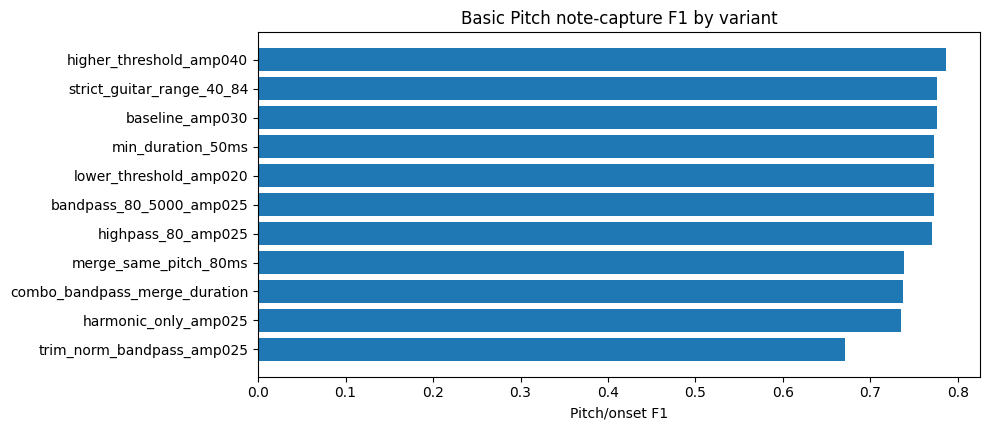

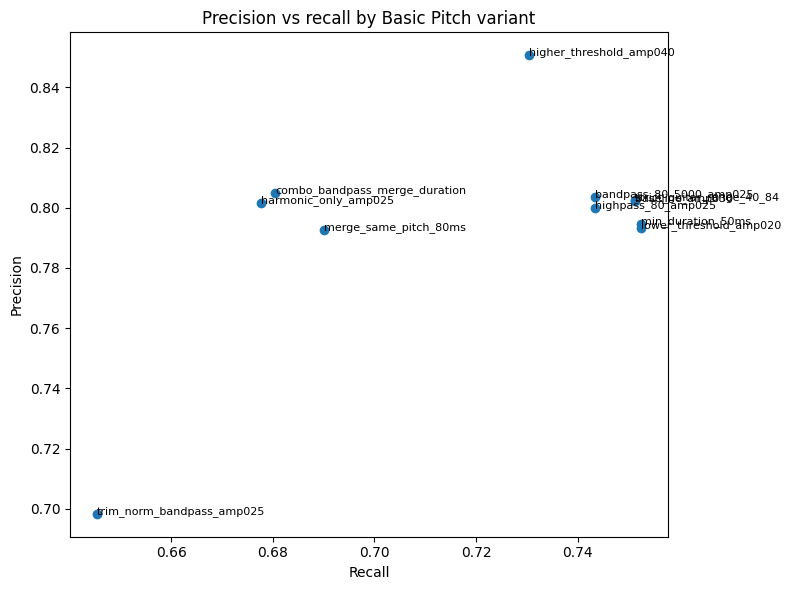

In [14]:
import matplotlib.pyplot as plt

if not summary_df.empty:
    plot_df = summary_df.sort_values('pitch_f1', ascending=True)

    plt.figure(figsize=(10, max(4, 0.4 * len(plot_df))))
    plt.barh(plot_df['variant'], plot_df['pitch_f1'])
    plt.xlabel('Pitch/onset F1')
    plt.title('Basic Pitch note-capture F1 by variant')
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(8, 6))
    plt.scatter(summary_df['pitch_recall'], summary_df['pitch_precision'])
    for _, row in summary_df.iterrows():
        plt.annotate(row['variant'], (row['pitch_recall'], row['pitch_precision']), fontsize=8)
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Precision vs recall by Basic Pitch variant')
    plt.tight_layout()
    plt.show()
else:
    print('Run the experiment cell first to create summary_df.')



## 10. Error inspection helpers

Use these after running the experiment to inspect what a variant is missing or hallucinating.


In [15]:
def show_record_variant_errors(recording, variant, n=30):
    print(f'Recording: {recording} | Variant: {variant}')
    print('\nFalse positives: predicted by Basic Pitch but no GT pitch/onset match')
    if false_pos_df.empty:
        print('No false_pos_df available.')
    else:
        fp = false_pos_df[(false_pos_df['recording'] == recording) & (false_pos_df['variant'] == variant)].copy()
        cols = [c for c in ['start', 'duration', 'midi', 'note_name', 'amplitude'] if c in fp.columns]
        display(fp[cols].sort_values(['start', 'midi']).head(n))

    print('\nMissed GT notes: in GuitarSet but not captured by Basic Pitch')
    if missed_df.empty:
        print('No missed_df available.')
    else:
        miss = missed_df[(missed_df['recording'] == recording) & (missed_df['variant'] == variant)].copy()
        cols = [c for c in ['start', 'duration', 'midi', 'pitch_class', 'true_string', 'true_fret'] if c in miss.columns]
        display(miss[cols].sort_values(['start', 'midi']).head(n))


def show_best_and_worst_records(variant=None, n=10):
    if metrics_df.empty:
        print('Run experiments first.')
        return
    df = metrics_df.copy()
    if variant is not None:
        df = df[df['variant'] == variant]
    print('Best records by pitch_f1:')
    display(df.sort_values('pitch_f1', ascending=False).head(n)[['recording', 'variant', 'n_gt_notes', 'n_pred_notes', 'pitch_precision', 'pitch_recall', 'pitch_f1']])
    print('\nWorst records by pitch_f1:')
    display(df.sort_values('pitch_f1', ascending=True).head(n)[['recording', 'variant', 'n_gt_notes', 'n_pred_notes', 'pitch_precision', 'pitch_recall', 'pitch_f1']])

# Example usage after running experiments:
# show_best_and_worst_records('baseline_amp030')
# show_record_variant_errors(recording='00_Jazz3-150-D_comp', variant='baseline_amp030', n=50)



## 11. Optional: quick threshold sweep

Use this to test amplitude thresholds more granularly without editing `EXPERIMENT_VARIANTS` above. This is useful if the baseline has low recall or too many false positives.


In [16]:
def make_threshold_sweep_variants(thresholds=None, min_midi=40, max_midi=88):
    thresholds = thresholds or [0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50]
    return [
        {
            'name': f'threshold_{t:.2f}'.replace('.', 'p'),
            'amplitude_threshold': float(t),
            'min_midi': min_midi,
            'max_midi': max_midi,
        }
        for t in thresholds
    ]

# Uncomment to run only threshold sweep variants.
# EXPERIMENT_VARIANTS = make_threshold_sweep_variants()
# Then rerun the experiment suite cell.



## 12. What to send back for interpretation

Send back these files, or paste the top rows from the displayed tables:

```text
basic_pitch_variant_summary_weighted.csv
basic_pitch_variant_comparison_vs_baseline.csv
basic_pitch_variant_metrics_by_record.csv
```

The summary tells us which idea wins overall. The by-record metrics tell us whether the improvement is real or just coming from a few easy recordings.
